# 03 — Clustering & Segmentation

K-Means on `StandardScaler`-transformed, `log1p`-treated seller features, with an
honest DBSCAN stress test and a PCA(2) projection used strictly for visualization.
Produces the artifacts consumed by the Streamlit app's Segmentation and Profiles tabs.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from src import clustering, config, data_loader, features, profiling

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)


In [2]:
tables, _ = data_loader.load_and_validate()
reviews_dedup = data_loader.dedupe_reviews(tables["order_reviews"])
reference_date = tables["orders"]["order_purchase_timestamp"].max()

pairs = features.build_seller_order_pairs(tables["order_items"], tables["orders"])
pairs = features.attach_review_scores(pairs, reviews_dedup)
seller_features = features.build_seller_features(pairs, reference_date)
seller_features = features.add_log_features(seller_features)
eligible, excluded = features.apply_min_order_threshold(seller_features)
print(f"eligible: {len(eligible):,}")

eligible: 1,794


## 1. Feature correlation -- does the candidate set need trimming?

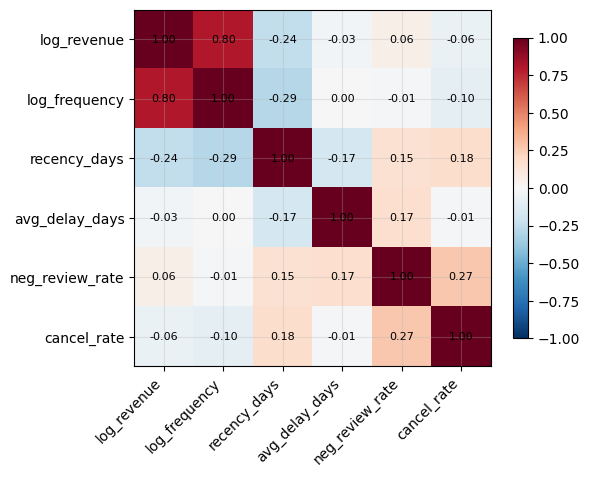

In [3]:
corr = eligible[config.CANDIDATE_FEATURES].corr(method="pearson")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

`log_revenue` and `log_frequency` correlate at **0.80** -- comfortably past the ~0.7 flag
threshold. Keeping both would double-weight one underlying "scale" dimension in Euclidean
distance. **Decision: drop `log_frequency` from the clustering feature set, keep
`log_revenue`.** Revenue already captures both order count and ticket size and is the
more business-critical axis for GMV-based prioritization; frequency is not discarded from
the project, it still feeds the health score and every profile card. See
`config.CLUSTER_FEATURES` vs `config.CANDIDATE_FEATURES`.

In [4]:
X = eligible[config.CLUSTER_FEATURES].to_numpy()
config.CLUSTER_FEATURES

['log_revenue',
 'recency_days',
 'avg_delay_days',
 'neg_review_rate',
 'cancel_rate']

## 2. Scaler choice

K-Means uses Euclidean distance. `MinMaxScaler` is defined by the extremes of each feature, so a single outlier compresses the other 99% of points into a narrow slice of that dimension, effectively erasing it from the distance calculation. `StandardScaler` (z-score) preserves relative structure and, combined with the `log1p` already applied to revenue, leaves every feature reasonably well-behaved. `RobustScaler` (median/IQR-based) was considered as a third option and would be worth an A/B check if outliers dominated post-log1p -- they don't here, so the simpler, more common choice (`StandardScaler`) is used.

## 3. k selection -- elbow & silhouette

In [5]:
elbow_df = clustering.elbow_silhouette(X)
elbow_df

,k,inertia,silhouette
0,2,7269.698205,0.405059
1,3,6014.274156,0.352687
2,4,5008.752279,0.231473
3,5,4285.547626,0.249667
4,6,3920.483524,0.234415
5,7,3675.461345,0.244738
6,8,3457.967874,0.195503
7,9,3254.831411,0.197953
8,10,3077.392754,0.203219


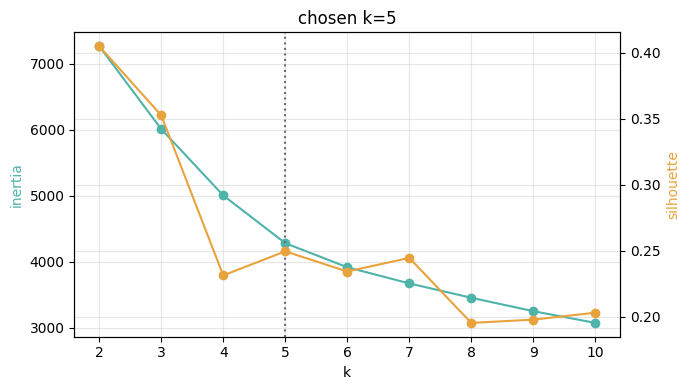

In [6]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(elbow_df["k"], elbow_df["inertia"], "o-", color="#4FB3A9")
ax1.set_xlabel("k"); ax1.set_ylabel("inertia", color="#4FB3A9")
ax2 = ax1.twinx()
ax2.plot(elbow_df["k"], elbow_df["silhouette"], "o-", color="#E8A33D")
ax2.set_ylabel("silhouette", color="#E8A33D")
ax1.axvline(config.N_CLUSTERS, color="#666C79", linestyle=":")
ax1.set_title(f"chosen k={config.N_CLUSTERS}")
plt.tight_layout()
plt.show()

The elbow flattens from k=4 onward -- it narrows the candidate range, it doesn't pick a
winner. Silhouette's **global** maximum is the coarse k=2 solution (0.41); k=5 is a
**local** peak (0.25, higher than both k=4's 0.23 and k=6's 0.23) but not the statistical
optimum. This is expected for continuous behavioral data with no natural density valleys
between clusters -- a modest silhouette is not a red flag here, it's the shape of the
problem (see the DBSCAN section below, which hits the same wall from a different angle).

**k=5 is chosen on business interpretability, not silhouette alone**: k=2/3 collapse
segments that need opposite actions (e.g. a healthy low-volume seller and a
quality-risk seller both fall into one "small seller" bucket at k=2), which defeats the
purpose of a segmentation meant to drive differentiated partner actions.

## 4. Stability check -- Adjusted Rand Index across seeds

Clusters that survive re-initialization are real structure, not an artifact of a lucky starting point.

In [7]:
stability_df = clustering.stability_ari(X, k=config.N_CLUSTERS)
print(f"mean pairwise ARI across {len(config.STABILITY_SEEDS)} seeds: {stability_df['ari'].mean():.3f}")
stability_df

mean pairwise ARI across 5 seeds: 0.980


,seed_a,seed_b,ari
0,1,7,0.979627
1,1,21,0.996109
2,1,42,0.967467
3,1,99,0.992307
4,7,21,0.983490
5,7,42,0.958204
6,7,99,0.987279
7,21,42,0.971303
8,21,99,0.996193
9,42,99,0.968807


An ARI this close to 1.0 across independent seeds means the k=5 partition is essentially deterministic given this feature space -- not sensitive to K-Means' random initialization.

## 5. DBSCAN -- a critical stress test, not a competing segmenter

DBSCAN finds clusters as dense regions separated by density valleys. Seller performance features form a continuous gradient with no such valleys, so the honest expectation is one giant cluster plus a noise fraction -- and that's what should show up below.

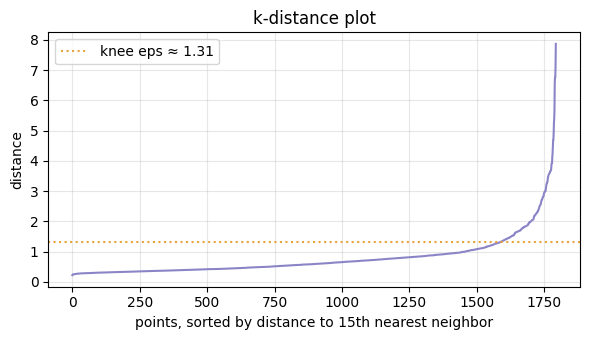

In [8]:
kth_dist = clustering.k_distance_data(X, k=config.DBSCAN_MIN_SAMPLES)
eps_knee = clustering.estimate_eps_from_knee(kth_dist)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(kth_dist, color="#8B85C7")
ax.axhline(eps_knee, color="#E8A33D", linestyle=":", label=f"knee eps ≈ {eps_knee:.2f}")
ax.set_xlabel(f"points, sorted by distance to {config.DBSCAN_MIN_SAMPLES}th nearest neighbor")
ax.set_ylabel("distance")
ax.legend()
ax.set_title("k-distance plot")
plt.tight_layout()
plt.show()

In [9]:
sweep = []
for mult in [0.5, 0.75, 1.0, 1.25, 1.5]:
    r = clustering.run_dbscan(X, eps=eps_knee * mult)
    r.pop("labels")
    r["eps_multiplier"] = mult
    sweep.append(r)
pd.DataFrame(sweep)

,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette_core_points,eps_multiplier
0,0.654,15,1,554,30.9,None,0.50
1,0.982,15,1,205,11.4,None,0.75
2,1.309,15,1,126,7.0,None,1.00
3,1.636,15,1,86,4.8,None,1.25
4,1.963,15,1,52,2.9,None,1.50


As eps grows from half the knee to 1.5x the knee, the noise fraction falls monotonically
(from ~30% toward single digits) while the cluster count never rises above 1 -- there is no
eps that produces several well-separated, business-meaningful clusters. DBSCAN either
strands a large minority of sellers as noise or collapses everyone into one blob,
confirming the density-based assumption doesn't hold on this feature space.

**Reframing the result as insight rather than a dead end:** the points DBSCAN flags as
noise are, by definition, sellers sitting in sparse regions of the feature space --
behavioral outliers. Cross-referencing that noise set against the K-Means segments (next
section) turns a "failed" second algorithm into an outlier-detection cross-check on the
first one.

## 6. PCA -- for the scatter plot only, never the clustering space

In [10]:
pca_coords, explained_var = clustering.pca_projection(X)
print(f"explained variance: PC1={explained_var[0]:.1%}, PC2={explained_var[1]:.1%}, "
      f"sum={explained_var.sum():.1%}")

explained variance: PC1=29.0%, PC2=24.7%, sum=53.6%


PC1+PC2 explain **~54%** of variance -- below the ~60% mark that would let the 2D
scatter be read as a faithful map of inter-cluster distance. The projection below is
**illustrative**: useful for seeing that clusters occupy distinguishable regions, not for
reading exact distances between them. Clustering itself was run on the original 5
scaled features, each with direct business meaning, precisely so centroids translate
back into "this segment has high revenue / high recency" rather than an uninterpretable
PCA axis.

## 7. Final model, cluster profiles, and segment naming

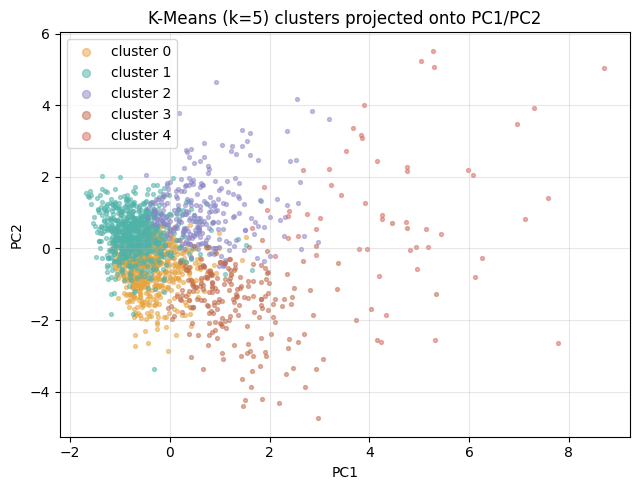

In [11]:
final_pipe = clustering.fit_final_model(X, k=config.N_CLUSTERS)
eligible = eligible.copy()
eligible["cluster"] = final_pipe.named_steps["kmeans"].labels_
eligible["pc1"], eligible["pc2"] = pca_coords[:, 0], pca_coords[:, 1]

fig, ax = plt.subplots(figsize=(6.5, 5))
colors = ["#E8A33D", "#4FB3A9", "#8B85C7", "#C1694A", "#D6685F"]
for c, color in zip(sorted(eligible["cluster"].unique()), colors):
    sub = eligible[eligible["cluster"] == c]
    ax.scatter(sub["pc1"], sub["pc2"], s=8, alpha=0.5, color=color, label=f"cluster {c}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(markerscale=2)
ax.set_title("K-Means (k=5) clusters projected onto PC1/PC2")
plt.tight_layout()
plt.show()

In [12]:
bounds = profiling.fit_health_score_bounds(eligible)
eligible["health_score"] = profiling.compute_health_score(eligible, bounds)

grand_total_revenue = seller_features["total_revenue"].sum()
grand_total_sellers = len(seller_features)
profile_table = profiling.build_cluster_profile_table(
    eligible, total_revenue=grand_total_revenue, total_sellers=grand_total_sellers
)
cluster_to_key = profiling.name_segments(profile_table, eligible)
profile_table["segment_name"] = profile_table["cluster"].map(
    lambda c: profiling.SEGMENT_META[cluster_to_key[c]]["name"]
)
profile_table[["cluster", "segment_name", "n_sellers", "seller_share_pct", "revenue_share_pct", "median_health"]]

,cluster,segment_name,n_sellers,seller_share_pct,revenue_share_pct,median_health
0,1,Premium & Consistent,678,21.906300,80.796762,73.346491
1,0,Emerging,608,19.644588,5.638770,64.302476
2,2,Underperforming - Quality Risk,254,8.206785,5.167340,56.987643
3,3,Declining,201,6.494346,3.390266,56.968857
4,4,At Risk / Low Engagement,53,1.712439,0.819276,50.632471


Names are assigned by rank (healthiest -> Premium, most inactive of the rest ->
Declining, least healthy remainder -> At Risk, and the final two split by health into
Emerging / Underperforming), never by raw cluster id, since K-Means labels are arbitrary
integers that carry no meaning on their own.

Worth flagging honestly: the original design sketch anticipated a "high volume, low
quality" archetype. It doesn't appear in the real k=5 solution -- above-median order
frequency only shows up in the healthiest cluster. Quality problems (elevated negative
reviews, worse delivery delay) concentrate in **low/mid-volume** sellers instead. The
segment name and description reflect what the data actually shows.

## 8. Health score distribution within each segment

A named segment can still hide an internal tail worth acting on.

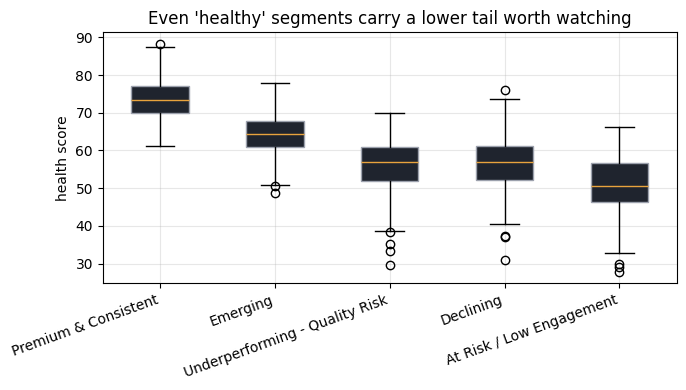

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
order = profile_table.sort_values("median_health", ascending=False)["cluster"]
data = [eligible.loc[eligible["cluster"] == c, "health_score"] for c in order]
labels = [profiling.SEGMENT_META[cluster_to_key[c]]["name"] for c in order]
ax.boxplot(data, tick_labels=labels, patch_artist=True,
           boxprops=dict(facecolor="#1F242E", color="#9CA1AD"),
           medianprops=dict(color="#E8A33D"))
plt.xticks(rotation=20, ha="right")
ax.set_ylabel("health score")
ax.set_title("Even 'healthy' segments carry a lower tail worth watching")
plt.tight_layout()
plt.show()

## Next

Run `python scripts/build_pipeline.py` to regenerate the processed artifacts (`data/processed/*.parquet`, `cluster_profiles.json`, `model_diagnostics.json`) that the Streamlit app in `app/streamlit_app.py` reads at boot -- the app itself trains nothing.